# Week 1 — Data Acquisition & EDA

# Dataset Inspection

### Loading the dataset

We use Pandas to load and inspect the Bank Marketing dataset.

 df stores our dataset as a DataFrame.And the goal is Understand the dataset before cleaning or analyzing it.

In [29]:
import pandas as pd
import seaborn as sns

In [30]:
#loading dataset
df = pd.read_csv("../../data/bank-full.csv")

In [31]:
# display 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [32]:
# check rows and column
df.shape

(45211, 17)

In [33]:
# check column names
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [34]:
# check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [35]:
# check missing values

df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

There is no missing values

In [36]:
# check duplicate rows
df.duplicated().sum()

np.int64(0)

Duplicate Rows also Zero

In [37]:
# check data types
df.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

In [38]:
# check unique values in each column
df.nunique()

age            77
job            12
marital         3
education       4
default         2
balance      7168
housing         2
loan            2
contact         3
day            31
month          12
duration     1573
campaign       48
pdays         559
previous       41
poutcome        4
y               2
dtype: int64

In [39]:
# check categorical values

#Display unique job categories
df['job'].unique()

<StringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',        'admin.',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str

In [40]:
# Display unique education categories

df["education"].unique()  

<StringArray>
['tertiary', 'secondary', 'unknown', 'primary']
Length: 4, dtype: str

In [41]:
 # Display target categories

df["y"].unique()

<StringArray>
['no', 'yes']
Length: 2, dtype: str

We inspect the actual categories in important categorical columns.

 Helps identify unexpected or inconsistent values before analysis.

In [42]:
# generate summary statistics

df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


# Summary Statistics
Shows count, mean, standard deviation, minimum and maximum.

Helps identify unusual or extreme values.


In [43]:
# count customer in every category

df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

# Target Variable

`y` is the target variable of the dataset.

- `yes` = customer subscribed

- `no` = customer did not subscribe


In [44]:
# calculate in percentage

df['y'].value_counts(normalize=True)*100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

# Target Distribution

The target variable is not evenly distributed.

- `no` = 88.30%

- `yes` = 11.70%

 Most customers did not subscribe to the term deposit.

In [45]:
# get summary statistics of customer age
df['age'].describe()

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

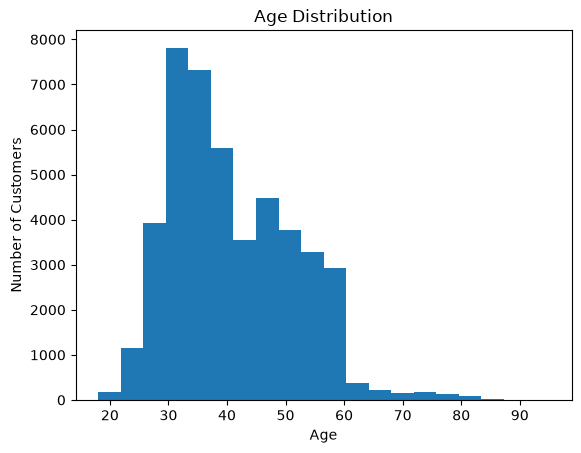

In [46]:
# create histogram of customer ages
import matplotlib.pyplot as plt

df['age'].plot(kind="hist", bins=20)
plt.title("Age Distribution")  
plt.xlabel("Age")
plt.ylabel("Number of Customers")  
plt.show()  

# Age Histogram

The histogram shows how customer ages are distributed.

- Most customers are between 30 and 50 years old.

- The highest concentration is around the 30–40 age range.

- Older customers are less frequent.



In [47]:
# get summary of statistics of customer balance

df['balance'].describe()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

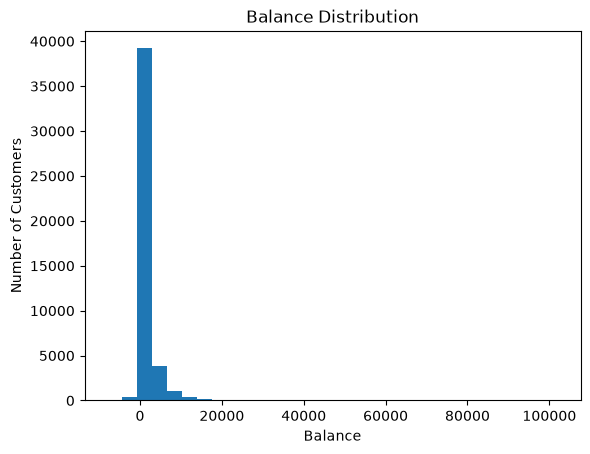

In [48]:
# Create a histogram of customer balances

df["balance"].plot(kind="hist", bins=30)  
plt.title("Balance Distribution") 
plt.xlabel("Balance") 
plt.ylabel("Number of Customers")
plt.show() 

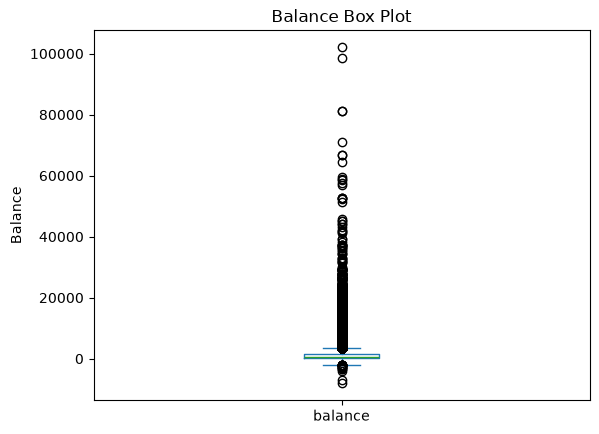

In [49]:
df["balance"].plot(kind="box")  # Create a box plot to identify unusual balance values
plt.title("Balance Box Plot")  # Add chart title
plt.ylabel("Balance")  # Label y-axis
plt.show()  # Display the chart

# Balance Box Plot

The box plot shows several potential outliers in the `balance` variable.

- Many observations lie beyond the upper whisker.

- Some customers have extremely high balances.

- Negative extreme values are also present.

- The outliers will be retained because they may represent genuine customer values.

- Further analysis can investigate their effect on the dataset.

In [50]:
# Count customers in each job category

df['job'].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

# Job Distribution

The `job` variable shows the occupational categories of customers.

- Blue-collar customers are the largest group.

- Management and technician customers are also highly represented.

- Student and unknown categories have fewer customers.

- Job category distribution can help us understand customer segments.

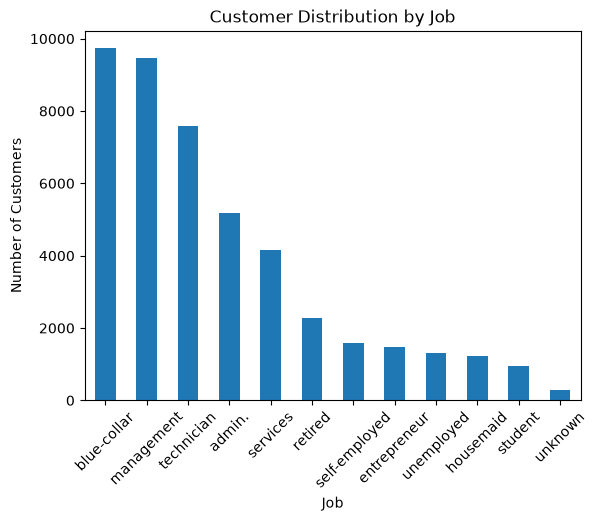

In [51]:
# Create a bar chart of job categories

df["job"].value_counts().plot(kind="bar")  
plt.title("Customer Distribution by Job")  
plt.xlabel("Job")  
plt.ylabel("Number of Customers") 
plt.xticks(rotation=45)  
plt.show()  

The chart shows that blue-collar, management, and technician customers make up most of the dataset, while student and unknown categories have fewer customers. Overall, the customers come from a variety of job backgrounds.


In [52]:
 # Count customers in each education category
df['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

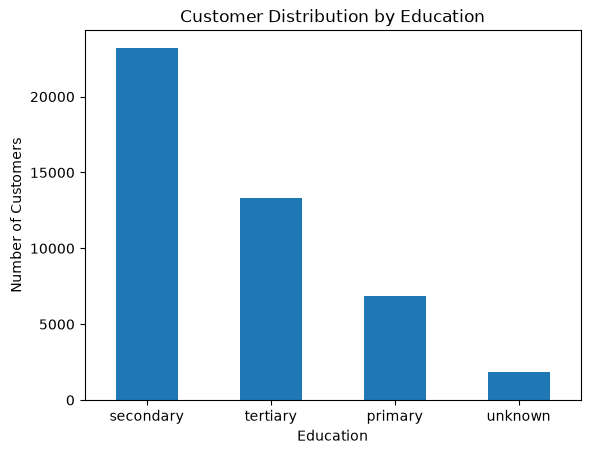

In [53]:
 # Create a bar chart of education categories

df["education"].value_counts().plot(kind="bar") 
plt.title("Customer Distribution by Education") 
plt.xlabel("Education") 
plt.ylabel("Number of Customers") 
plt.xticks(rotation=0) 
plt.show()

### Education Distribution

The dataset contains customers with different levels of education. Most customers have secondary education, followed by tertiary and primary education. A smaller number of customers have an unknown education level.

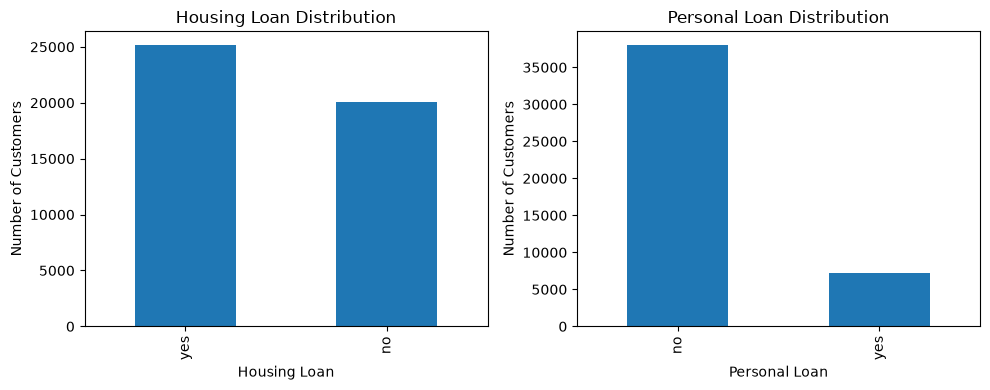

In [54]:
housing_counts = df["housing"].value_counts()
loan_counts = df["loan"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
housing_counts.plot(kind="bar", ax=axes[0])

# Add title and labels to the housing chart
axes[0].set_title("Housing Loan Distribution")
axes[0].set_xlabel("Housing Loan")
axes[0].set_ylabel("Number of Customers")

# Create the personal loan bar chart
loan_counts.plot(kind="bar", ax=axes[1])

# Add title and labels to the personal loan chart
axes[1].set_title("Personal Loan Distribution")
axes[1].set_xlabel("Personal Loan")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()

plt.show()

### Housing and Loan Distribution

The chart shows that housing loans are common among the customers, while personal loans are less common. Most customers do not have a personal loan.

# Correlation Analysis

A correlation heatmap helps us understand the relationships between numerical variables in the dataset.

- Values closer to 1 indicate a strong positive relationship.

- Values closer to -1 indicate a strong negative relationship.

- Values closer to 0 indicate a weak relationship.

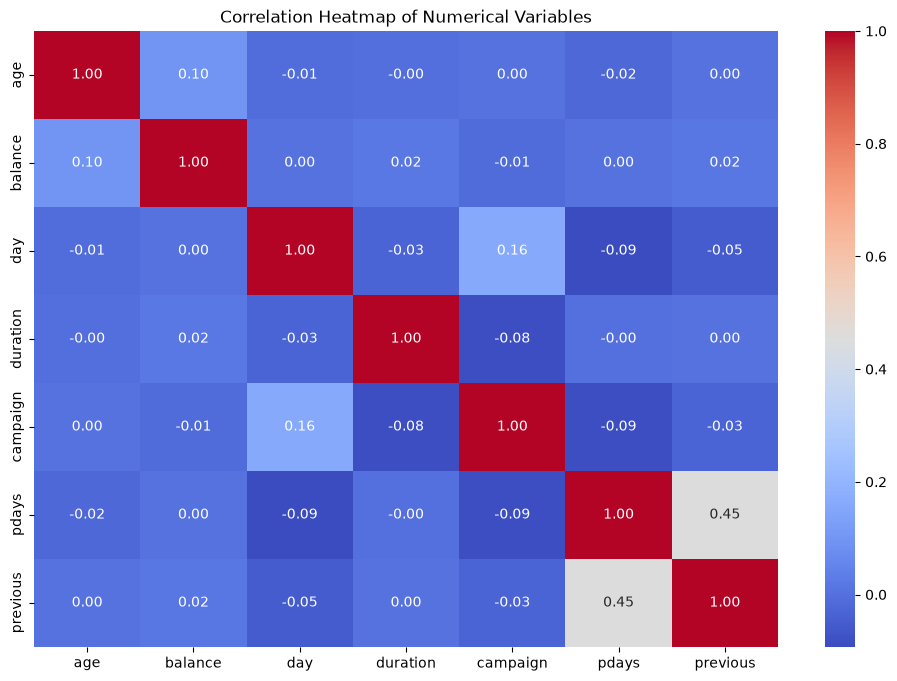

In [55]:
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()

# Create the heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

### Correlation Analysis

The heatmap shows that most numerical variables have weak correlations with each other. The strongest relationship is between `pdays` and `previous`, with a correlation of about 0.45. Overall, there are no very strong linear relationships among the numerical variables.

# Job vs Subscription

This chart compares customers' job categories with their term-deposit subscription status. It helps us identify whether subscription patterns differ across different job groups.

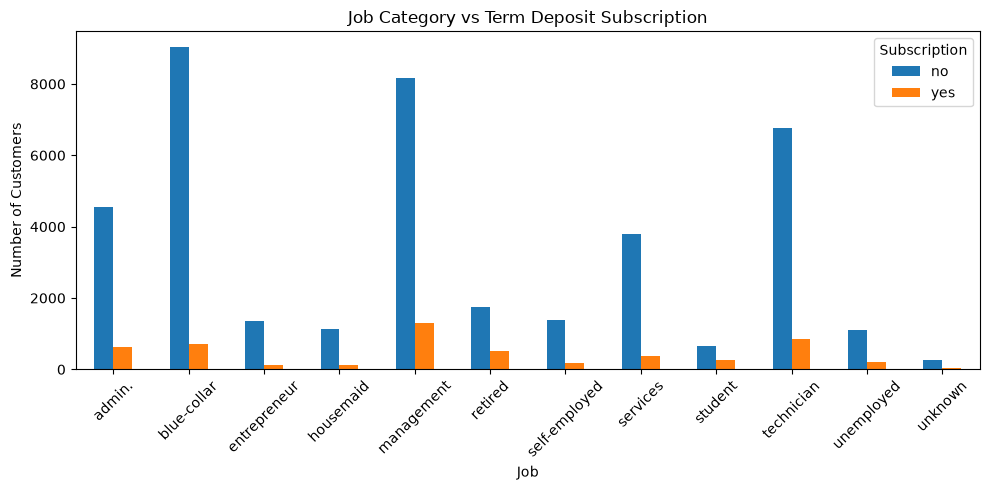

In [56]:
job_subscription = pd.crosstab(df["job"], df["y"])

# Create a stacked bar chart
job_subscription.plot(kind="bar", figsize=(10, 5))

plt.title("Job Category vs Term Deposit Subscription")

plt.xlabel("Job")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.legend(title="Subscription")
plt.tight_layout()
plt.show()

# Job vs Subscription

The chart shows that customers from different job categories have different subscription patterns. Blue-collar, management, and technician customers form the largest groups, while the number of customers who subscribed is much smaller across most job categories.

# Overall EDA Findings

The dataset contains customers from different age groups, jobs, education levels, and financial backgrounds.

The data is generally clean, with no missing values or duplicate rows found during the initial checks.

Most customers are around 30–50 years old, while the balance variable is strongly right-skewed because a small number of customers have very high balances.

The customer base is mainly made up of blue-collar, management, and technician workers. Most customers have secondary education.

The target variable is imbalanced, with most customers not subscribing to the term deposit. This should be considered in later analysis and machine learning evaluation.

The correlation analysis shows that most numerical variables have weak relationships with each other. The strongest observed relationship is between `pdays` and `previous`.

The job and subscription analysis shows that subscription counts are smaller across most job categories, although the number of customers varies considerably between job groups.